<a href="https://colab.research.google.com/github/Orzilber/computationl-statistics/blob/main/Metropolis_Hastings_Examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:97: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:97: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_21593/569816469.py:97: SyntaxWarning: invalid escape sequence '\m'
  axes[1].plot(running_means, color='dodgerblue', label='Running Estimate of $\mathbb{E}[X-Y]$')
/tmp/ipykernel_21593/569816469.py:100: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title('MCMC Convergence of $\mathbb{E}[X-Y]$ (Independence Sampler)')


Starting MCMC run with 100000 iterations...
MCMC Complete.
Acceptance Rate: 28.92%
Estimated E[X - Y] (after burn-in): 1.0954
Theoretical E[X - Y]: 0.0000 (Due to symmetry of f(x,y) = f(y,x))


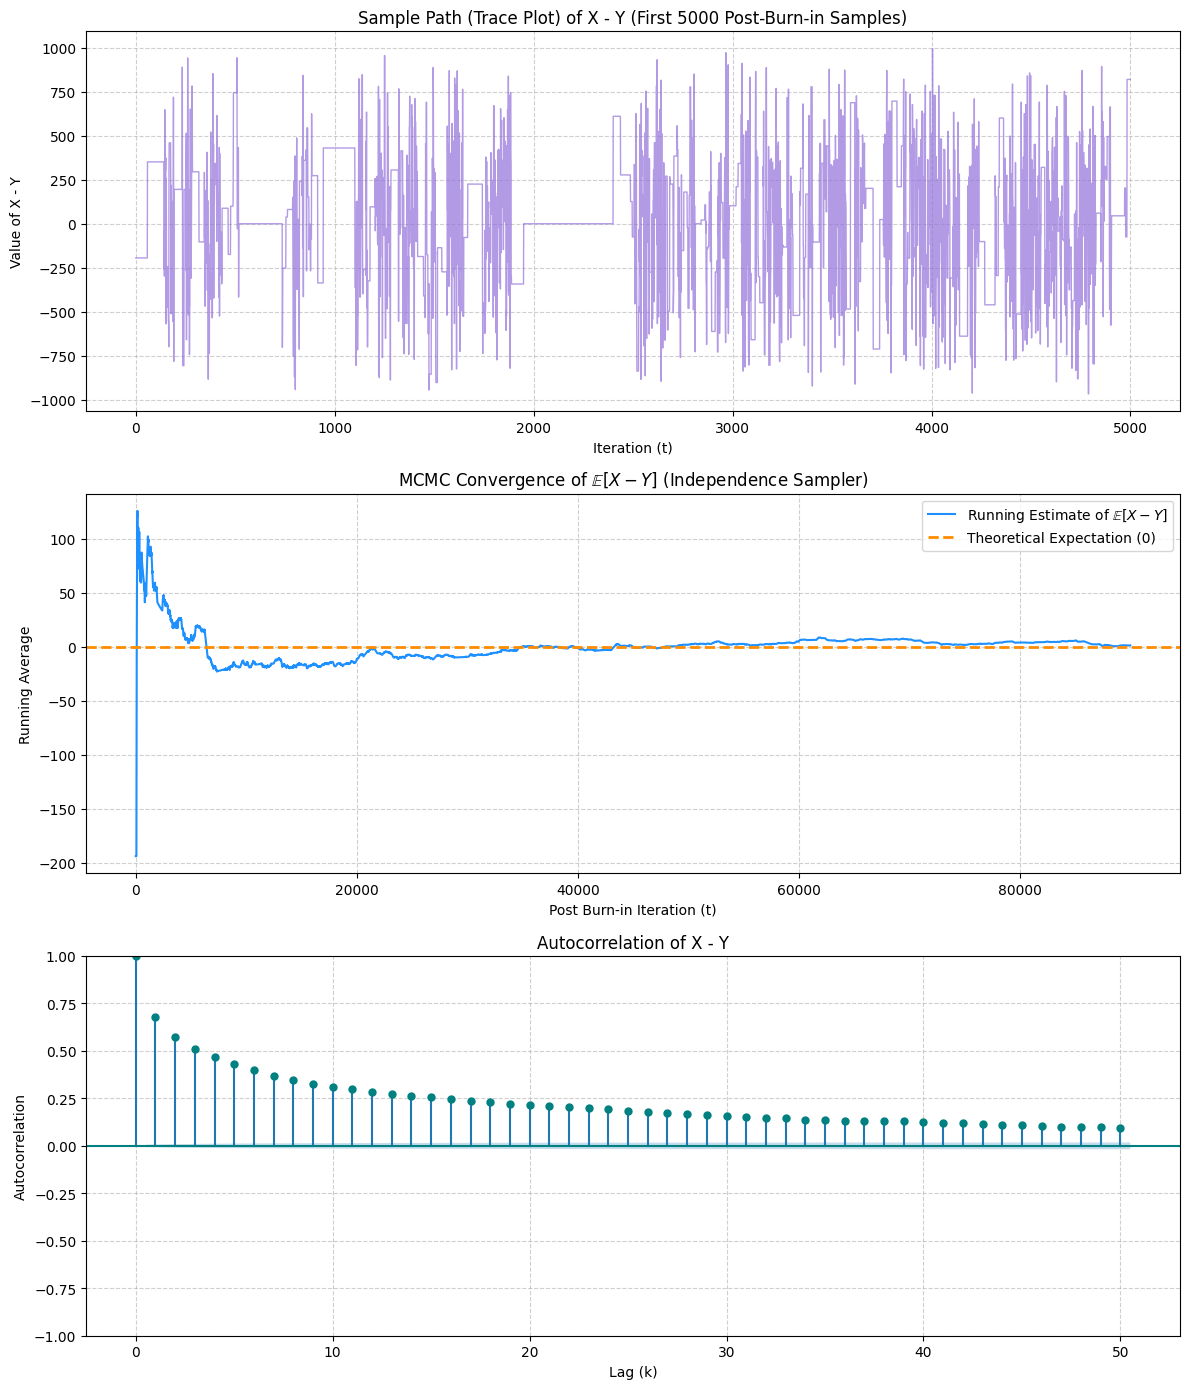

In [4]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# ==========================================
# 1. Configuration
# ==========================================
# The grid size (x, y are between 1 and N)
N = 1000

# MCMC parameters
num_iterations = 100000  # Total number of MH steps
burn_in = 10000          # Number of initial steps to discard

print(f"Starting MCMC run with {num_iterations} iterations...")

# ==========================================
# 2. Metropolis-Hastings Initialization
# ==========================================
# We want to estimate E[X - Y].
# We will store the value of (X - Y) at each step.
samples_x_minus_y = np.zeros(num_iterations)

# Choose an arbitrary starting state uniformly
current_x = random.randint(1, N)
current_y = random.randint(1, N)
current_gcd = math.gcd(current_x, current_y)

accepted_moves = 0

# ==========================================
# 3. Metropolis-Hastings Loop (Independence Sampler)
# ==========================================
for t in range(num_iterations):
    # Step A: Propose a new state (x', y') from the Uniform proposal distribution
    prop_x = random.randint(1, N)
    prop_y = random.randint(1, N)
    prop_gcd = math.gcd(prop_x, prop_y)

    # Step B: Calculate the acceptance ratio (alpha)
    # Since the proposal g(x,y) is uniform, the terms g(x'|x) and g(x|x') cancel out.
    # The normalizing constant Z also cancels out.
    # We are left with alpha = f(x', y') / f(x, y) = GCD(x', y') / GCD(x, y)
    acceptance_ratio = prop_gcd / current_gcd

    # Step C: Accept or Reject
    # If ratio >= 1, we always accept. If < 1, we accept with probability alpha.
    if acceptance_ratio >= 1.0 or random.random() < acceptance_ratio:
        current_x = prop_x
        current_y = prop_y
        current_gcd = prop_gcd
        accepted_moves += 1

    # Record the value of our target function h(X,Y) = X - Y for this step
    # Notice that if rejected, we record the EXACT SAME state again!
    samples_x_minus_y[t] = current_x - current_y

# ==========================================
# 4. Post-Processing & Estimation
# ==========================================
# Discard the burn-in period to ensure we are sampling from the stationary distribution
valid_samples = samples_x_minus_y[burn_in:]

# Calculate the final expectation estimate using the Ergodic Theorem (Time Average)
expectation_estimate = np.mean(valid_samples)
acceptance_rate = accepted_moves / num_iterations

print(f"MCMC Complete.")
print(f"Acceptance Rate: {acceptance_rate * 100:.2f}%")
print(f"Estimated E[X - Y] (after burn-in): {expectation_estimate:.4f}")

# Calculate theoretical expectation due to symmetry
print(f"Theoretical E[X - Y]: 0.0000 (Due to symmetry of f(x,y) = f(y,x))")

# ==========================================
# 5. Diagnostics Visualization
# ==========================================
# We will create a 3-panel figure to show the trace, the running mean, and the ACF.
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# --- Plot 1: Sample Path (Trace Plot) ---
# To make the plot readable, we only plot a subset (e.g., the first 5000 valid samples)
# Plotting 100,000 points creates a solid unreadable block of color.
samples_to_plot = 5000
axes[0].plot(valid_samples[:samples_to_plot], color='mediumpurple', alpha=0.7, linewidth=1)
axes[0].set_title(f'Sample Path (Trace Plot) of X - Y (First {samples_to_plot} Post-Burn-in Samples)')
axes[0].set_xlabel('Iteration (t)')
axes[0].set_ylabel('Value of X - Y')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Running Mean (Ergodic Theorem) ---
# Calculate the cumulative running mean of the valid samples
running_means = np.cumsum(valid_samples) / np.arange(1, len(valid_samples) + 1)

axes[1].plot(running_means, color='dodgerblue', label='Running Estimate of $\mathbb{E}[X-Y]$')
axes[1].axhline(y=0, color='darkorange', linestyle='--', linewidth=2, label='Theoretical Expectation (0)')

axes[1].set_title('MCMC Convergence of $\mathbb{E}[X-Y]$ (Independence Sampler)')
axes[1].set_xlabel('Post Burn-in Iteration (t)')
axes[1].set_ylabel('Running Average')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# --- Plot 3: Autocorrelation Function (ACF) ---
# We calculate the autocorrelation for the first 50 lags.
# This shows how quickly the chain "forgets" where it was.
plot_acf(valid_samples, ax=axes[2], lags=50, color='teal', title='Autocorrelation of X - Y')
axes[2].set_xlabel('Lag (k)')
axes[2].set_ylabel('Autocorrelation')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#SAW

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import rc
from IPython.display import HTML

# --- COLAB CONFIGURATION ---
rc('animation', html='jshtml')

# --- CORE LOGIC ---
def get_pivot_transforms():
    return [
        lambda x, y: (y, -x), lambda x, y: (-y, x),
        lambda x, y: (-x, y), lambda x, y: (x, -y),
        lambda x, y: (-x, -y), lambda x, y: (-y, -x),
        lambda x, y: (y, x), lambda x, y: (x, y)
    ]

def is_valid(walk):
    return len(set(walk)) == len(walk)

def apply_pivot(walk, pivot_idx, transform):
    pivot = np.array(walk[pivot_idx])
    new_walk = list(walk[:pivot_idx + 1])
    for i in range(pivot_idx + 1, len(walk)):
        pt = np.array(walk[i]) - pivot
        tx, ty = transform(pt[0], pt[1])
        new_walk.append(tuple(np.array([tx, ty]) + pivot))
    return new_walk

def is_straight(walk):
    """Checks if the walk is a straight line (horizontal or vertical)."""
    xs = [pt[0] for pt in walk]
    ys = [pt[1] for pt in walk]
    return len(set(xs)) == 1 or len(set(ys)) == 1

# Heuristic to force "untangling" for the demo
def propose_move(walk):
    # Try random pivots
    for _ in range(20):
        pivot_idx = np.random.randint(0, len(walk) - 1)
        transform = get_pivot_transforms()[np.random.randint(0, 8)]
        candidate = apply_pivot(walk, pivot_idx, transform)

        # Bias: Check if candidate is "straighter" (fewer y-deviations)
        if is_valid(candidate):
            score_curr = sum(abs(pt[1]) for pt in walk)
            score_cand = sum(abs(pt[1]) for pt in candidate)
            # Accept if it's a valid SAW and (it's straighter OR random luck)
            if score_cand < score_curr or np.random.random() < 0.2:
                return candidate
    return walk

# --- INITIALIZATION ---
N = 15
# Walk A: Starts with a sharp U-turn
walk_a = [(0,0), (0,1), (1,1), (1,0), (2,0)]
# Walk B: Starts with a zig-zag
walk_b = [(0,0), (1,0), (1,1), (2,1), (2,0)]
canonical = [(i, 0) for i in range(N+1)]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
plt.close()

def update(frame):
    global walk_a, walk_b

    # Only propose moves if the walk hasn't reached a straight state
    if not is_straight(walk_a):
        walk_a = propose_move(walk_a)
    if not is_straight(walk_b):
        walk_b = propose_move(walk_b)

    for ax, walk, title in [(ax1, walk_a, "Walk A"), (ax2, walk_b, "Walk B"), (ax3, canonical, "Canonical SAW")]:
        ax.clear()
        ax.plot(*zip(*walk), 'o-', lw=3, color='#0b57d0')
        ax.set_title(title)
        ax.set_xlim(-2, N+2); ax.set_ylim(-5, 5)
        ax.grid(True, alpha=0.3)

ani = FuncAnimation(fig, update, frames=80, interval=200)
HTML(ani.to_jshtml())